In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cmocean as cm
import xgcm
import colorcet as ccm

In [2]:
from dask.distributed import Client

In [3]:
c = Client()
c 

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 48,Total memory: 503.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36286,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38443,Total threads: 6
Dashboard: http://127.0.0.1:43349/status,Memory: 62.90 GiB
Nanny: tcp://127.0.0.1:37138,


In [4]:
from xmitgcm import open_mdsdataset

In [5]:
from utils import *

In [6]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

In [7]:

data = dict(dz8={"PATH":"run_z512_dz8/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz2={"PATH":"run_z512_dz2/", "expt":{}})

ISOBLJ_vels = ISOBLJ_Struct(input_data,data=data)

In [8]:
ISOBLJ_vels.open_datasets(prefix=['vels','state2D'])


ISOBLJ_vels.data['dz8']['expt'].pop("c80m_Td2_vshift8_ryan_dz8");
ISOBLJ_vels.data['dz4']['expt'].pop("c80m_Td2_vshift16_ryan_dz4");

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [9]:
Uvel = ISOBLJ_vels.get_variable("UVEL")
Vvel = ISOBLJ_vels.get_variable("VVEL")
Wvel = ISOBLJ_vels.get_variable("WVEL")

SHIuStar = ISOBLJ_vels.get_variable("SHIuStar")
# ISOBLJ_vels.data

In [10]:
grids = ISOBLJ_vels._get_grid()

In [11]:
def coord_dtype(ds):
    for coord in ds.coords:
        ds[coord]= ds[coord].astype(np.float64)
    return ds

Uvel = coord_dtype(Uvel.astype(float))
Vvel = coord_dtype(Vvel.astype(float))
Wvel = coord_dtype(Wvel.astype(float))

In [12]:
# uv_ = []
# vv_ = []
# wv_ = []

# ### ADD hFactors


# for var in np.sort(Vvel.data_vars):
#     print(var)
#     grid = grids[var.split("VVEL"+"_")[1]]
#     # Uvel_interp = grid.interp(Uvel[var.replace("VVEL","UVEL")],'X',boundary="extend")
#     # try:
#     dz = int(var.split("dz")[-1])
#     if dz==2:
#         continue
#     zcoord = "Z_dz{0}".format(dz)
#     hfacS = Vvel[var.replace("VVEL","hFacS")]
#     hfacW = Uvel[var.replace("VVEL","hFacW")]
    
#     Vvel_fac = (Vvel[var] * hfacS).rename({zcoord:"Z"})
#     Vvel_fac = Vvel_fac.where(Vvel_fac!=0,np.nan)

#     Uvel_fac = ( Uvel[var.replace("VVEL","UVEL")] * hfacW ).rename({zcoord:"Z"})
#     Uvel_fac = Uvel_fac.where(Uvel_fac!=0,np.nan)

#     zcoord_ = "Zl_dz{0}".format(dz)
#     Wvel_fac = Wvel[var.replace("VVEL","WVEL")].rename({zcoord_:"Zl"})
#     Wvel_fac = Wvel_fac.where(Wvel_fac!=0,np.nan)
    
#     Vvel_interp = grid.interp(Vvel_fac,'Y')
#     Uvel_interp = grid.interp(Uvel_fac,'X')
#     Wvel_interp = grid.interp(Wvel_fac,'Z')
    
#     uv_.append((Uvel_interp*(60*4)*Vvel_interp).rename(var.replace("VVEL","udvdx")).rename({"Z":zcoord}))
#     vv_.append((Vvel_interp*(60*4)*Vvel_interp).rename(var.replace("VVEL","vdvdy")).rename({"Z":zcoord}))
#     wv_.append((Wvel_interp*(60*60)*Vvel_interp).rename(var.replace("VVEL","wdvdz")).rename({"Z":zcoord_}))
#     # break
#     # except:
#         # print(var, " failed")
#         # pass`
        
# uv = xr.merge(uv_)
# vv = xr.merge(vv_)
# wv = xr.merge(wv_)



VVEL_c0m_Td01_vshift12_dz8
VVEL_c0m_Td01_vshift24_dz4
VVEL_c0m_Td01_vshift48_dz2
VVEL_c0m_Td05_vshift12_dz8
VVEL_c0m_Td05_vshift24_dz4
VVEL_c0m_Td05_vshift48_dz2
VVEL_c0m_Td1_vshift12_dz8
VVEL_c0m_Td1_vshift24_dz4
VVEL_c0m_Td1_vshift48_dz2
VVEL_c0m_Td2_vshift12_dz8
VVEL_c0m_Td2_vshift24_dz4
VVEL_c0m_Td2_vshift48_dz2
VVEL_c120m_Td01_vshift12_dz8
VVEL_c120m_Td01_vshift24_dz4
VVEL_c120m_Td05_vshift12_dz8
VVEL_c120m_Td05_vshift24_dz4
VVEL_c120m_Td1_vshift12_dz8
VVEL_c120m_Td1_vshift24_dz4
VVEL_c120m_Td2_vshift12_dz8
VVEL_c120m_Td2_vshift24_dz4
VVEL_c160m_Td01_vshift12_dz8
VVEL_c160m_Td01_vshift24_dz4
VVEL_c160m_Td01_vshift48_dz2
VVEL_c160m_Td05_vshift12_dz8
VVEL_c160m_Td05_vshift24_dz4
VVEL_c160m_Td05_vshift48_dz2
VVEL_c160m_Td1_vshift12_dz8
VVEL_c160m_Td1_vshift24_dz4
VVEL_c160m_Td1_vshift48_dz2
VVEL_c160m_Td2_vshift12_dz8
VVEL_c160m_Td2_vshift24_dz4
VVEL_c160m_Td2_vshift48_dz2
VVEL_c20m_Td01_vshift12_dz8
VVEL_c20m_Td01_vshift24_dz4
VVEL_c20m_Td05_vshift12_dz8
VVEL_c20m_Td05_vshift24_dz4


In [13]:
# uv_shift = shifted_dataset(uv,method = "du")
# vv_shift = shifted_dataset(vv,method = "du")
# wv_shift = shifted_dataset(wv,method = "du")

# Output from model

In [14]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

data = dict(dz2={"PATH":"run_z512_dz2/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz8={"PATH":"run_z512_dz8/", "expt":{}})

ISOBLJ_adv = ISOBLJ_Struct(input_data,data=data)

data = dict(dz2={"PATH":"run_z512_dz2/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz8={"PATH":"run_z512_dz8/", "expt":{}})

ISOBLJ_mom = ISOBLJ_Struct(input_data,data=data)

In [15]:
ISOBLJ_adv.open_datasets(prefix=['ADV_terms'])
ISOBLJ_mom.open_datasets(prefix=['MOM_tend'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run
expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
exp

In [16]:
ADVx_Um = ISOBLJ_adv.get_variable("ADVx_Um")
ADVy_Um = ISOBLJ_adv.get_variable("ADVy_Um")
ADVrE_Um = ISOBLJ_adv.get_variable("ADVrE_Um")
ADVx_Vm = ISOBLJ_adv.get_variable("ADVx_Vm")
ADVy_Vm = ISOBLJ_adv.get_variable("ADVy_Vm")
ADVrE_Vm = ISOBLJ_adv.get_variable("ADVrE_Vm")

ADVv = ISOBLJ_mom.get_variable("Vm_Advec")

c80m_Td2_vshift16_ryan_dz4 does not have var ADVx_Um
c80m_Td2_vshift16_ryan_dz4 does not have var ADVy_Um
c80m_Td2_vshift16_ryan_dz4 does not have var ADVrE_Um
c80m_Td2_vshift16_ryan_dz4 does not have var ADVx_Vm
c80m_Td2_vshift16_ryan_dz4 does not have var ADVy_Vm
c80m_Td2_vshift16_ryan_dz4 does not have var ADVrE_Vm
c80m_Td2_vshift16_ryan_dz4 does not have var Vm_Advec


In [17]:
ISOBLJ_mom

In [18]:
input_data = "/data/hpcflash/users/josnez/ISOBLJ/ISOBLJ/"

data = dict(dz2={"PATH":"run_z512_dz2/", "expt":{}},
            dz4={"PATH":"run_z512_dz4/", "expt":{}},
            dz8={"PATH":"run_z512_dz8/", "expt":{}})

ISOBLJ_vel = ISOBLJ_Struct(input_data,data=data)

In [19]:
ISOBLJ_vel.open_datasets(prefix=['vels'])

expt c120m_Td05_vshift48_dz2 has not run
expt c20m_Td05_vshift48_dz2 has not run
expt c120m_Td01_vshift48_dz2 has not run
expt c120m_Td1_vshift48_dz2 has not run
expt c120m_Td2_vshift48_dz2 has not run
expt c20m_Td01_vshift48_dz2 has not run
expt c60m_Td05_vshift48_dz2 has not run
expt c40m_Td05_vshift48_dz2 has not run
expt c60m_Td2_vshift48_dz2 has not run
expt c20m_Td2_vshift48_dz2 has not run
expt c20m_Td1_vshift48_dz2 has not run
expt c60m_Td01_vshift48_dz2 has not run
expt c40m_Td2_vshift48_dz2 has not run
expt c60m_Td1_vshift48_dz2 has not run
expt c40m_Td1_vshift48_dz2 has not run
expt c40m_Td01_vshift48_dz2 has not run


In [20]:
VVEL = ISOBLJ_vel.get_variable("VVEL")
hfacc_ = shifted_dataset(VVEL.reset_coords(),method = "du")

In [21]:
# hfacc_shifted =  hfacc_.hFacS_c80m_Td1_vshift24_dz4.isel(XC=0).T
# dz=4
# z_shift=-512
# z_ = (abs(((np.sum( 1 - hfacc_shifted ,axis=0))  * dz) + z_shift) + z_shift)
# z_ = np.repeat(z_, 2) 
# # z_£.plot()
# plt.plot(z_)

In [22]:
from matplotlib.collections import PolyCollection
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

def plot_hfacc_surf_shifted(ax,ds,dz,z_shift=512):
    
    x_ = (ds.YC - 60/2000)
    x_ = np.append(np.roll(np.repeat(x_, 2),-1)[:-1], x_[-1]+60/2000)
    Hfacc_shifted = shifted_computations(ds.hFacC,method="du").mean("XC").T

    z_ = (abs(((np.sum( 1 - Hfacc_shifted ,axis=0))  * dz) + z_shift) + z_shift) + dz
    z_ = np.repeat(z_, 2) 

    x = np.append(np.hstack((0 ,x_)),x_[-1]+120/2000)
    if z_shift==-512:
        z = np.append(np.hstack((0 ,z_)),0)
    else:
        z = np.append(np.hstack((z_shift ,z_)),z_shift)

    verts = [np.array(list(zip(x, z)))]
    # print(verts)
    
    poly = PolyCollection(verts, alpha=1, zorder=1,
                          facecolors=[[0.9, 0.9, 0.9]])
    ax.add_collection(poly)

def plot_channel_surface_property(ax,z,ds,dz,freq=1,**kwargs):
    top = ds.dropna("time").isel(time=-1).mean("XC")
    x = ds.YC[::freq] - 60/2000
    cbar = ax.scatter(x, z, c=top,**kwargs)
    return cbar

def extract_channel_coords(ds,dz,shift=0,freq=1):
    z =((np.max(np.cumsum( abs(ds.hFacC.isel(XC=0) -1 ),axis=0),axis=0) * -dz) + 512 + shift )[::freq]
    return z

z = extract_channel_coords(VVEL["hFacS_c80m_Td2_vshift48_dz2"].rename({"hFacS_c80m_Td2_vshift48_dz2":"hFacC"}),dz=2)

In [30]:
def VAR_withBL_TopZ(ds_vel,adv,grids,var='VVEL',dims="X"):
    ds_return=[]
    for dvar in adv.data_vars:
        print(dvar)
        dz = int(dvar.split("dz")[-1])
        z_coord = "Z_dz{0}".format(dz)
        grid_name = "_".join(dvar.split("_")[2:])
        hfacc_var = ds_vel["hFacS_"+grid_name].rename({z_coord:"Z"})
        grid = grids[grid_name]
        # hfacc_var = grid.interp(grid.interp(hfacc_var,'Y'),'X')
        if dims=="Z":
            data = adv.reset_coords(drop=True)[dvar].rename({z_coord.replace("Z","Zl"):"Zl"})
        else:
            data = adv.reset_coords(drop=True)[dvar].rename({z_coord:"Z"})

        volx = (60*60*hfacc_var*dz)
        
        adv_ = grid.diff(data.mean("time"),dims).where(hfacc_var!=0,0)/volx
        
        adv_shift = shifted_computations(adv_,method = "ud")

        # break
    # return adv_shift
    #     # shifted_computations(adv_,method = "ud")
    #     # print(adv_)
    #     #This only works for a constant dz
        hfacc_shifted = shifted_computations(hfacc_var, method="ud",dims=["Z"] )
        
        drK0 = hfacc_shifted.isel({"Z":0}) * dz
        drK1 = (1 - hfacc_shifted.isel({"Z":0})) * dz
        
        recip_drLoc = 1/ ( drK0 + drK1 )
        advvar = (adv_shift.isel({"Z":0}) * drK0 + adv_shift.isel({"Z":1}) * drK1)

        weighted_var = adv_shift.isel({"Z":0}) #
        weighted_var = advvar*recip_drLoc
        # break
    # return weighted_var
        ds_return.append(weighted_var.rename(dvar).rename({"Z":z_coord}))
        # break
        
    return xr.merge(ds_return)


In [31]:
Vvel = ISOBLJ_vel.get_variable("VVEL")

In [32]:
ADVx_Vm_vars = ADVx_Vm[[ "ADVx_Vm_c80m_Td2_vshift48_dz2","ADVx_Vm_c80m_Td2_vshift24_dz4","ADVx_Vm_c80m_Td2_vshift12_dz8",
                        "ADVx_Vm_c160m_Td2_vshift48_dz2","ADVx_Vm_c160m_Td2_vshift24_dz4","ADVx_Vm_c160m_Td2_vshift12_dz8" ]]

ADVx_Vm_surf = VAR_withBL_TopZ(Vvel,ADVx_Vm_vars,grids,dims="X")

ADVx_Vm_c80m_Td2_vshift48_dz2
ADVx_Vm_c80m_Td2_vshift24_dz4
ADVx_Vm_c80m_Td2_vshift12_dz8
ADVx_Vm_c160m_Td2_vshift48_dz2
ADVx_Vm_c160m_Td2_vshift24_dz4
ADVx_Vm_c160m_Td2_vshift12_dz8


In [33]:
ADVy_Vm_vars = ADVy_Vm[[ "ADVy_Vm_c80m_Td2_vshift48_dz2","ADVy_Vm_c80m_Td2_vshift24_dz4","ADVy_Vm_c80m_Td2_vshift12_dz8",
                       "ADVy_Vm_c160m_Td2_vshift48_dz2","ADVy_Vm_c160m_Td2_vshift24_dz4","ADVy_Vm_c160m_Td2_vshift12_dz8" ]]

ADVy_Vm_surf = VAR_withBL_TopZ(Vvel,ADVy_Vm_vars,grids,dims="Y")

ADVy_Vm_c80m_Td2_vshift48_dz2
ADVy_Vm_c80m_Td2_vshift24_dz4
ADVy_Vm_c80m_Td2_vshift12_dz8
ADVy_Vm_c160m_Td2_vshift48_dz2
ADVy_Vm_c160m_Td2_vshift24_dz4
ADVy_Vm_c160m_Td2_vshift12_dz8


In [34]:
ADVrE_Vm_vars = ADVrE_Vm[[ "ADVrE_Vm_c80m_Td2_vshift48_dz2","ADVrE_Vm_c80m_Td2_vshift24_dz4","ADVrE_Vm_c80m_Td2_vshift12_dz8",
                         "ADVrE_Vm_c160m_Td2_vshift48_dz2","ADVrE_Vm_c160m_Td2_vshift24_dz4","ADVrE_Vm_c160m_Td2_vshift12_dz8"]]

ADVrE_Vm_surf = VAR_withBL_TopZ(Vvel,ADVrE_Vm_vars,grids,dims="Z")

ADVrE_Vm_c80m_Td2_vshift48_dz2
ADVrE_Vm_c80m_Td2_vshift24_dz4
ADVrE_Vm_c80m_Td2_vshift12_dz8
ADVrE_Vm_c160m_Td2_vshift48_dz2
ADVrE_Vm_c160m_Td2_vshift24_dz4
ADVrE_Vm_c160m_Td2_vshift12_dz8


/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 28.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 28.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/_task_spec.py:768: RuntimeWa

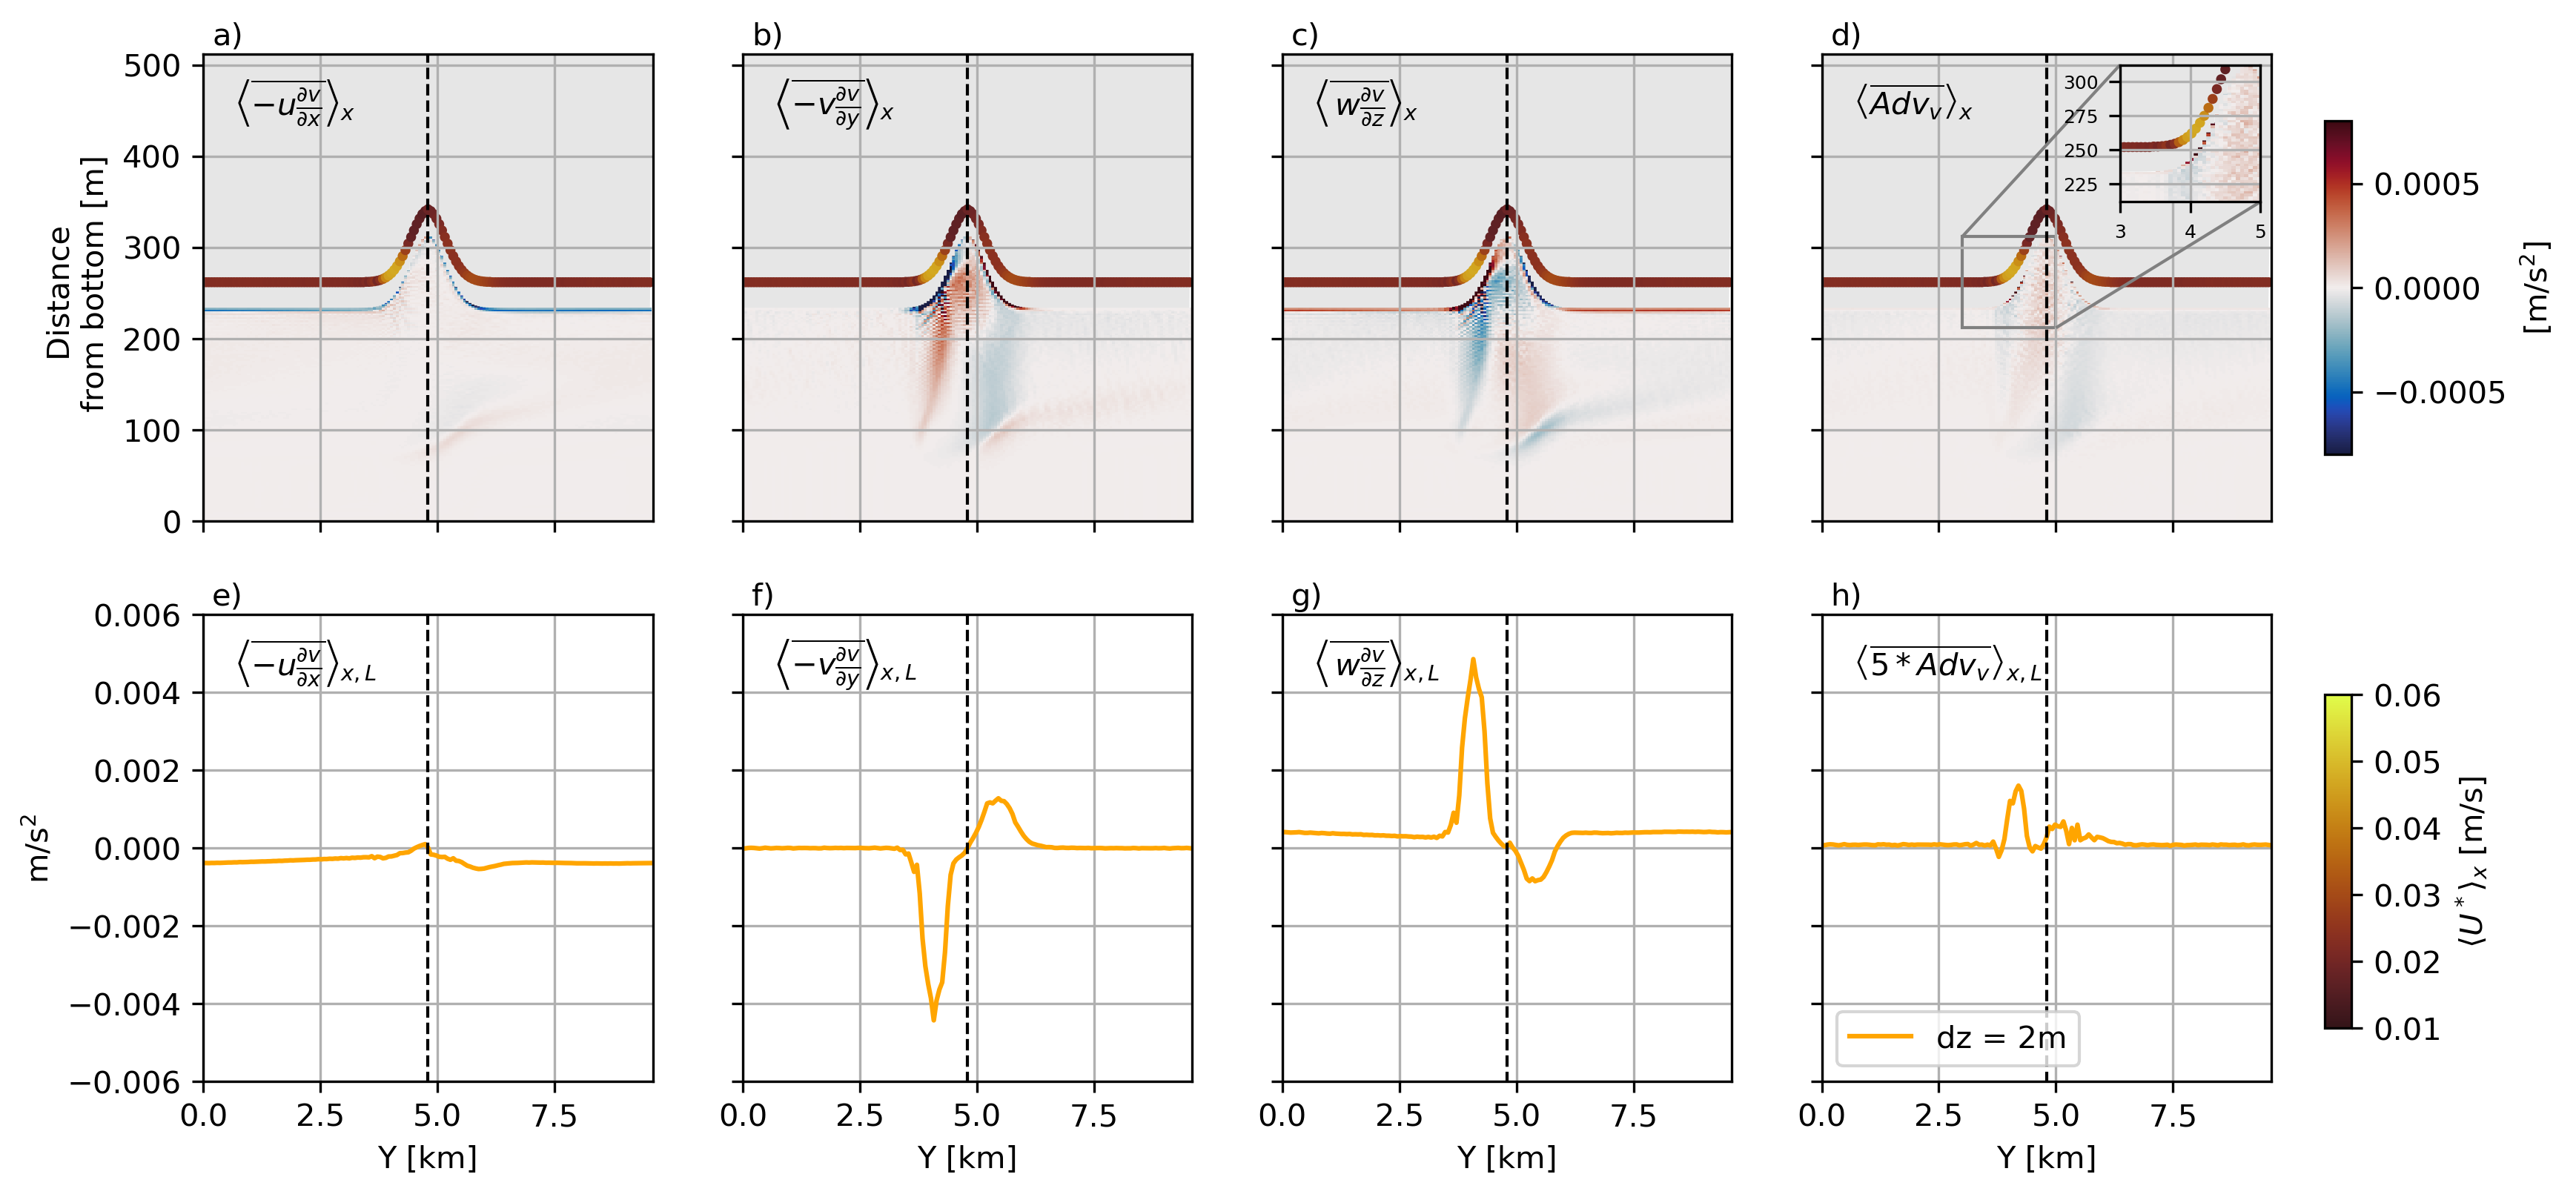

In [37]:
# ADVx_Vm_shift.ADVx_Vm_c120m_Td2_vshift24_dz4
# ADVy_Vm_shift.ADVy_Vm_c120m_Td2_vshift24_dz4
# ADVrE_Vm_shift.ADVrE_Vm_c120m_Td2_vshift24_dz4

fig,ax = plt.subplots(2,4,figsize=(12,6),dpi=300)

kwargs={ 
    "cmap":cm.cm.balance,
    "vmin":-8e-4,
    "vmax":8e-4,
    "add_colorbar":False,
    "rasterized":True
}

kwargs_ustar={ 
    "cmap":cm.cm.solar,
    "vmin":0.01,
    "vmax":0.06,
}

grids = ISOBLJ_vel._get_grid()


grid = grids["c80m_Td2_vshift48_dz2"]

volx = (60*60*hfacc_.hFacS_c80m_Td2_vshift48_dz2*2).rename({"Z_dz2":"Z"})
mask = volx.where(volx==0).astype(bool)

adv_x = ADVx_Vm.ADVx_Vm_c80m_Td2_vshift48_dz2.rename({"Z_dz2":"Z"})
adv_y = ADVy_Vm.ADVy_Vm_c80m_Td2_vshift48_dz2.rename({"Z_dz2":"Z"})
adv_z = ADVrE_Vm.ADVrE_Vm_c80m_Td2_vshift48_dz2.rename({"Zl_dz2":"Zl"})

udvdx = shifted_computations(-grid.diff(adv_x.mean("time"),"X"),method = "du").compute() * mask
vdvdy = shifted_computations(-grid.diff(adv_y.mean("time"), "Y"),method = "du").compute() * mask
wdvdz = shifted_computations(grid.diff(adv_z.mean("time"), "Z"),method = "du").compute() * mask


cbar1 = (udvdx/volx).mean(("XC")).plot(x="YG",ax=ax[0,0],**kwargs)

(vdvdy/volx).mean(("XC")).plot(x="YG",ax=ax[0,1],**kwargs)

(wdvdz/volx).mean(("XC")).plot(x="YG",ax=ax[0,2],**kwargs)

adv1 = (udvdx + vdvdy + wdvdz)/volx

adv1.mean(("XC")).plot(x="YG",ax=ax[0,3],**kwargs)

grid = grids["c80m_Td2_vshift48_dz2"]


plot_hfacc_surf_shifted(ax[0,0],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,1],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,2],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)

plot_hfacc_surf_shifted(ax[0,3],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)


z_dz2 = extract_channel_coords(VVEL["hFacS_c80m_Td2_vshift48_dz2"].rename({"hFacS_c80m_Td2_vshift48_dz2":"hFacC"}),dz=2)
cbar_ustar = plot_channel_surface_property(ax[0,0], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[0,1], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[0,2], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[0,3], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)

########################################################################
########################################################################
########################################################################

x1, x2, y1, y2 = 3, 5, -300, -200

axins1 = zoomed_inset_axes(ax[0, 3], 1.5, bbox_to_anchor=[0.21, 0.01, 0.8, 1], bbox_transform=ax[0,3].transAxes)
adv1.mean(("XC")).plot(x="YG",ax=axins1,**kwargs)

axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)

plot_hfacc_surf_shifted(axins1,
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)


plot_channel_surface_property(axins1, z_dz2-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)

[a.set_xlabel("",fontsize=5) for a in [axins1]]
[a.set_title("") for a in [axins1]]
[a.xaxis.label.set_size(6) for a in [axins1]]
[a.yaxis.label.set_size(6) for a in [axins1]]
[a.xaxis.set_tick_params(labelsize=6) for a in [axins1]]
[a.yaxis.set_tick_params(labelsize=6) for a in [axins1]]
[a.grid() for a in [axins1]]

ticklocations = [-287,-262,-237,-212]
[a.yaxis.set_ticks(ticklocations) for a in [axins1]]
ticklabels = [225,250,275,300]
[a.set_yticklabels(ticklabels) for a in [axins1]]

[a.set_ylabel("",fontsize=6) for a in [axins1]]

for a in ax[0,:]:
    a.plot(np.ones(2)*ADVx_Vm_surf.YG[80].values,[-512,0],linestyle='--',color='k',linewidth=1)

mark_inset(ax[0, 3], axins1, loc1=2, loc2=4, fc="none", ec="0.5")

########################################################################
########################################################################
########################################################################

grid = grids["c80m_Td2_vshift48_dz2"]

udvdx = -ADVx_Vm_surf.ADVx_Vm_c80m_Td2_vshift48_dz2
vdvdy = -ADVy_Vm_surf.ADVy_Vm_c80m_Td2_vshift48_dz2
wdvdz = ADVrE_Vm_surf.ADVrE_Vm_c80m_Td2_vshift48_dz2

(udvdx).mean("XC").plot(x="YG",ax=ax[1,0],color="orange")

(vdvdy).mean("XC").plot(x="YG",ax=ax[1,1],color="orange")

(wdvdz).mean("XC").plot(x="YG",ax=ax[1,2],color="orange")

adv1 = 5*(udvdx + vdvdy + wdvdz).mean("XC")

adv1.plot(x="YG",ax=ax[1,3],color="orange")


for a in ax[1,:]:
    a.plot(np.ones(2)*ADVx_Vm_surf.YG[80].values,[-0.012,0.012],linestyle='--',color='k',linewidth=1)

[a.set_ylabel("") for a in ax[1,:]]
[a.set_xlabel("") for a in ax[1,:]]
[a.set_ylim(-0.006,0.006) for a in ax[1,:]]

[a.set_title("") for a in ax[1,:]]


ax[1,3].plot(0,0,color='orange',label="dz = 2m",linestyle='-')
ax[1,3].legend()

########################################################################
########################################################################
########################################################################

ticklocations = [-512,-412,-312,-212,-112,-12]
[a.yaxis.set_ticks(ticklocations) for a in ax[0,:]]
ticklabels = [0,100,200,300,400,500]
[a.set_yticklabels(ticklabels) for a in ax[0,:]]

[a.yaxis.set_ticklabels([]) for a in ax[:,1:].ravel()]
[a.xaxis.set_ticklabels([]) for a in ax[0,:]]

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.set_xlim(0,9.6) for a in ax.ravel()]
[a.grid() for a in ax.ravel()]

[a.set_title("") for a in ax[0,:]]

ax[0,0].set_ylabel("Distance \n from bottom [m]")
[a.set_xlabel("Y [km]") for a in ax[1,:]]
ax[1,0].set_ylabel(r"$\mathrm{m/s}^2$")

# ax[0,0].set_ylabel("dz=2m \n Depth [m]")

ax[0,0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0,0].transAxes)
ax[0,1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[0,1].transAxes)
ax[0,2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[0,2].transAxes)
ax[0,3].text(0.02, 1.02, "d)", fontsize=10, transform=ax[0,3].transAxes)
ax[1,0].text(0.02, 1.02, "e)", fontsize=10, transform=ax[1,0].transAxes)
ax[1,1].text(0.02, 1.02, "f)", fontsize=10, transform=ax[1,1].transAxes)
ax[1,2].text(0.02, 1.02, "g)", fontsize=10, transform=ax[1,2].transAxes)
ax[1,3].text(0.02, 1.02, "h)", fontsize=10, transform=ax[1,3].transAxes)


ax[0,0].text(0.07, 0.87, r"$\left<\overline{-u\frac{\partial v}{\partial x}}\right>_x$", fontsize=10, transform=ax[0,0].transAxes)
ax[0,1].text(0.07, 0.87, r"$\left<\overline{-v\frac{\partial v}{\partial y}}\right>_x$", fontsize=10, transform=ax[0,1].transAxes)
ax[0,2].text(0.07, 0.87, r"$\left<\overline{\,w\frac{\partial v}{\partial z}}\right>_x$", fontsize=10, transform=ax[0,2].transAxes)
ax[0,3].text(0.07, 0.87, r"$\left<\overline{Adv_v}\right>_x$", fontsize=10, transform=ax[0,3].transAxes)

ax[1,0].text(0.07, 0.87, r"$\left<\overline{-u\frac{\partial v}{\partial x}}\right>_{x,L}$", fontsize=10, transform=ax[1,0].transAxes)
ax[1,1].text(0.07, 0.87, r"$\left<\overline{-v\frac{\partial v}{\partial y}}\right>_{x,L}$", fontsize=10, transform=ax[1,1].transAxes)
ax[1,2].text(0.07, 0.87, r"$\left<\overline{\,w\frac{\partial v}{\partial z}}\right>_{x,L}$", fontsize=10, transform=ax[1,2].transAxes)
ax[1,3].text(0.07, 0.87, r"$\left<\overline{5*Adv_v}\right>_{x,L}$", fontsize=10, transform=ax[1,3].transAxes)

cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.25])
fig.colorbar(cbar_ustar, cax =cbar_ax)
cbar_ax.set_ylabel(r"$\left<U^*\right>_x$ [m/s]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.92, 0.58, 0.01, 0.25])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"[$\mathrm{m/s}^2$]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

plt.savefig('./figures/Fig_7_advection.png', dpi=300, bbox_inches='tight')

## Supplementary figure to compare viscosities

/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 28.13 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/data/hpcdata/users/josnez/micromamba/envs/mitgcm/lib/python3.10/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_a

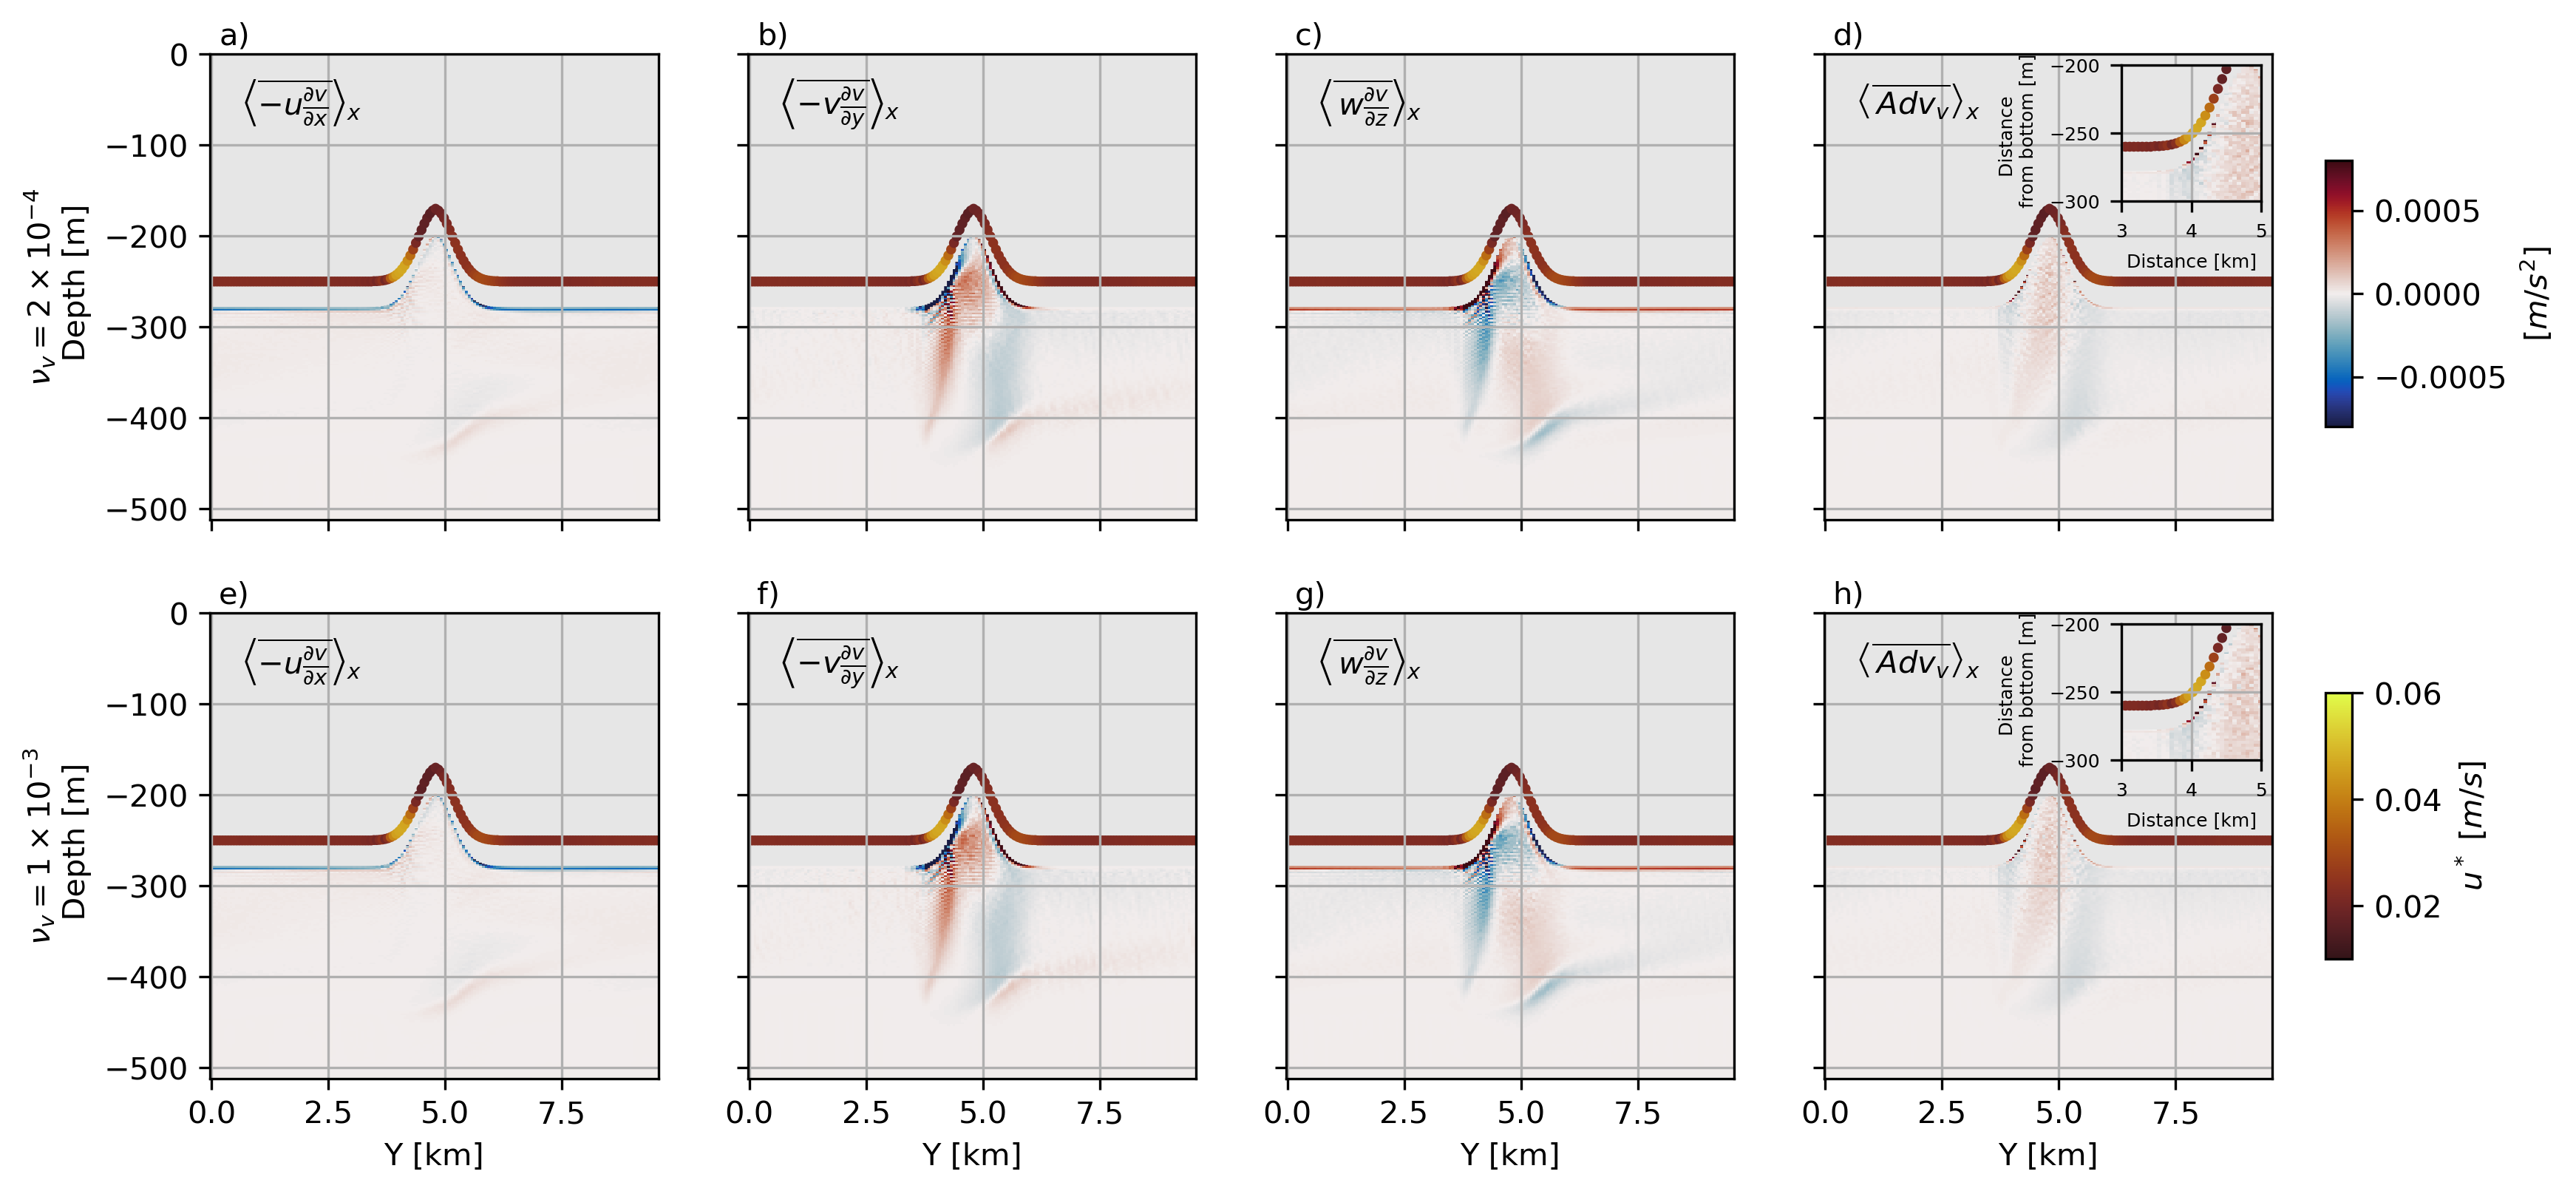

In [29]:
fig,ax = plt.subplots(2,4,figsize=(12,6),dpi=300,sharey=True, sharex=True)

kwargs={ 
    "cmap":cm.cm.balance,
    "vmin":-8e-4,
    "vmax":8e-4,
    "add_colorbar":False,
    "rasterized":True
}

kwargs_ustar={ 
    "cmap":cm.cm.solar,
    "vmin":0.01,
    "vmax":0.06,
}

grids = ISOBLJ_vel._get_grid()


grid = grids["c80m_Td2_vshift48_dz2"]

volx = (60*60*hfacc_.hFacS_c80m_Td2_vshift48_dz2*2).rename({"Z_dz2":"Z"})
mask = volx.where(volx==0).astype(bool)

adv_x = ADVx_Vm.ADVx_Vm_c80m_Td2_vshift48_dz2.rename({"Z_dz2":"Z"})
adv_y = ADVy_Vm.ADVy_Vm_c80m_Td2_vshift48_dz2.rename({"Z_dz2":"Z"})
adv_z = ADVrE_Vm.ADVrE_Vm_c80m_Td2_vshift48_dz2.rename({"Zl_dz2":"Zl"})

udvdx = shifted_computations(-grid.diff(adv_x.mean("time"),"X"),method = "du").compute() * mask
vdvdy = shifted_computations(-grid.diff(adv_y.mean("time"), "Y"),method = "du").compute() * mask
wdvdz = shifted_computations(grid.diff(adv_z.mean("time"), "Z"),method = "du").compute() * mask


cbar1 = (udvdx/volx).mean(("XC")).plot(x="YG",ax=ax[0,0],**kwargs)

(vdvdy/volx).mean(("XC")).plot(x="YG",ax=ax[0,1],**kwargs)

(wdvdz/volx).mean(("XC")).plot(x="YG",ax=ax[0,2],**kwargs)

adv1 = (udvdx + vdvdy + wdvdz)/volx

adv1.mean(("XC")).plot(x="YG",ax=ax[0,3],**kwargs)

grid = grids["c80m_Td2_vshift48_dz2"]


plot_hfacc_surf_shifted(ax[0,0],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,1],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[0,2],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)

plot_hfacc_surf_shifted(ax[0,3],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)


z_dz2 = extract_channel_coords(VVEL["hFacS_c80m_Td2_vshift48_dz2"].rename({"hFacS_c80m_Td2_vshift48_dz2":"hFacC"}),dz=2)
cbar_ustar = plot_channel_surface_property(ax[0,0], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[0,1], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[0,2], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[0,3], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)

########################################################################
########################################################################
########################################################################


grid = grids["c80m_Td2_vshift48_dz2"]

volx = (60*60*hfacc_.hFacS_c80m_Td2_vshift48_dz2*2).rename({"Z_dz2":"Z"})
mask = volx.where(volx==0).astype(bool)

adv_x = ADVx_Vm.ADVx_Vm_c80m_Td2_vshift48_visc_dz2.rename({"Z_dz2":"Z"})
adv_y = ADVy_Vm.ADVy_Vm_c80m_Td2_vshift48_visc_dz2.rename({"Z_dz2":"Z"})
adv_z = ADVrE_Vm.ADVrE_Vm_c80m_Td2_vshift48_visc_dz2.rename({"Zl_dz2":"Zl"})

udvdx = shifted_computations(-grid.diff(adv_x.mean("time"),"X"),method = "du").compute() * mask
vdvdy = shifted_computations(-grid.diff(adv_y.mean("time"), "Y"),method = "du").compute() * mask
wdvdz = shifted_computations(grid.diff(adv_z.mean("time"), "Z"),method = "du").compute() * mask


cbar1 = (udvdx/volx).mean(("XC")).plot(x="YG",ax=ax[1,0],**kwargs)

(vdvdy/volx).mean(("XC")).plot(x="YG",ax=ax[1,1],**kwargs)

(wdvdz/volx).mean(("XC")).plot(x="YG",ax=ax[1,2],**kwargs)

adv2 = (udvdx + vdvdy + wdvdz)/volx

adv2.mean(("XC")).plot(x="YG",ax=ax[1,3],**kwargs)

grid = grids["c80m_Td2_vshift48_dz2"]


plot_hfacc_surf_shifted(ax[1,0],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[1,1],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)
plot_hfacc_surf_shifted(ax[1,2],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)

plot_hfacc_surf_shifted(ax[1,3],
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)


z_dz2 = extract_channel_coords(VVEL["hFacS_c80m_Td2_vshift48_dz2"].rename({"hFacS_c80m_Td2_vshift48_dz2":"hFacC"}),dz=2)
cbar_ustar = plot_channel_surface_property(ax[1,0], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_visc_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[1,1], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_visc_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[1,2], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_visc_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(ax[1,3], z_dz2-482, SHIuStar.SHIuStar_c80m_Td2_vshift48_visc_dz2, dz=2, s=5,**kwargs_ustar)


########################################################################
########################################################################
########################################################################

x1, x2, y1, y2 = 3, 5, -300, -200

axins1 = zoomed_inset_axes(ax[0, 3], 1.5, bbox_to_anchor=[0.21, 0.01, 0.8, 1], bbox_transform=ax[0,3].transAxes)
adv1.mean(("XC")).plot(x="YG",ax=axins1,**kwargs)

axins1.set_xlim(x1, x2)
axins1.set_ylim(y1, y2)

plot_hfacc_surf_shifted(axins1,
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)

axins2 = zoomed_inset_axes(ax[1, 3], 1.5, bbox_to_anchor=[0.21, 0.01, 0.8, 1], bbox_transform=ax[1,3].transAxes)
adv2.mean(("XC")).plot(x="YG",ax=axins2,**kwargs)

axins2.set_xlim(x1, x2)
axins2.set_ylim(y1, y2)

plot_hfacc_surf_shifted(axins2,
                                VVEL.hFacS_c80m_Td2_vshift48_dz2.to_dataset(name="hFacC").rename({"YG":"YC","Z_dz2":"Z"}),
                                2,z_shift=-512)


plot_channel_surface_property(axins1, z_dz2-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_dz2, dz=2, s=5,**kwargs_ustar)
plot_channel_surface_property(axins2, z_dz2-492, SHIuStar.SHIuStar_c80m_Td2_vshift48_visc_dz2, dz=2, s=5,**kwargs_ustar)

[a.set_xlabel("Distance [km]") for a in [axins1,axins2]]
[a.set_title("") for a in [axins1,axins2]]
[a.xaxis.label.set_size(6) for a in [axins1,axins2]]
[a.yaxis.label.set_size(6) for a in [axins1,axins2]]
[a.xaxis.set_tick_params(labelsize=6) for a in [axins1,axins2]]
[a.yaxis.set_tick_params(labelsize=6) for a in [axins1,axins2]]
[a.grid() for a in [axins1,axins2]]

[a.set_ylabel("Distance \n from bottom [m]") for a in [axins1,axins2]]

########################################################################
########################################################################
########################################################################

[a.set_ylabel("") for a in ax.ravel()]
[a.set_xlabel("") for a in ax.ravel()]
[a.grid() for a in ax.ravel()]

[a.set_title("") for a in ax[0,:]]

# [a.set_ylabel("Depth [m]") for a in ax[:,0]]
[a.set_xlabel("Y [km]") for a in ax[1,:]]

ax[0,0].set_ylabel(r"$\nu_v=2\times10^{-4}$"+"\n Depth [m]")
ax[1,0].set_ylabel(r"$\nu_v=1\times10^{-3}$"+"\n Depth [m]")

ax[0,0].text(0.02, 1.02, "a)", fontsize=10, transform=ax[0,0].transAxes)
ax[0,1].text(0.02, 1.02, "b)", fontsize=10, transform=ax[0,1].transAxes)
ax[0,2].text(0.02, 1.02, "c)", fontsize=10, transform=ax[0,2].transAxes)
ax[0,3].text(0.02, 1.02, "d)", fontsize=10, transform=ax[0,3].transAxes)
ax[1,0].text(0.02, 1.02, "e)", fontsize=10, transform=ax[1,0].transAxes)
ax[1,1].text(0.02, 1.02, "f)", fontsize=10, transform=ax[1,1].transAxes)
ax[1,2].text(0.02, 1.02, "g)", fontsize=10, transform=ax[1,2].transAxes)
ax[1,3].text(0.02, 1.02, "h)", fontsize=10, transform=ax[1,3].transAxes)


ax[0,0].text(0.07, 0.87, r"$\left<\overline{-u\frac{\partial v}{\partial x}}\right>_x$", fontsize=10, transform=ax[0,0].transAxes)
ax[0,1].text(0.07, 0.87, r"$\left<\overline{-v\frac{\partial v}{\partial y}}\right>_x$", fontsize=10, transform=ax[0,1].transAxes)
ax[0,2].text(0.07, 0.87, r"$\left<\overline{\,w\frac{\partial v}{\partial z}}\right>_x$", fontsize=10, transform=ax[0,2].transAxes)
ax[0,3].text(0.07, 0.87, r"$\left<\overline{\,Adv_v}\right>_x$", fontsize=10, transform=ax[0,3].transAxes)
ax[1,0].text(0.07, 0.87, r"$\left<\overline{-u\frac{\partial v}{\partial x}}\right>_x$", fontsize=10, transform=ax[1,0].transAxes)
ax[1,1].text(0.07, 0.87, r"$\left<\overline{-v\frac{\partial v}{\partial y}}\right>_x$", fontsize=10, transform=ax[1,1].transAxes)
ax[1,2].text(0.07, 0.87, r"$\left<\overline{\,w\frac{\partial v}{\partial z}}\right>_x$", fontsize=10, transform=ax[1,2].transAxes)
ax[1,3].text(0.07, 0.87, r"$\left<\overline{\,Adv_v}\right>_x$", fontsize=10, transform=ax[1,3].transAxes)

cbar_ax = fig.add_axes([0.92, 0.2, 0.01, 0.2])
fig.colorbar(cbar_ustar, cax =cbar_ax)
cbar_ax.set_ylabel(r"$u^*$ [$m/s$]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

cbar_ax = fig.add_axes([0.92, 0.6, 0.01, 0.2])
fig.colorbar(cbar1, cax =cbar_ax)
cbar_ax.set_ylabel(r"[$m/s^2$]")
cbar_ax.yaxis.set_tick_params(labelsize=10)

plt.savefig('./figures/SFig_2_advection_visc.png', dpi=300, bbox_inches='tight')
